In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df = pd.read_csv("../results/tuning_ln.csv")

In [4]:

best_configs = df.groupby(['N', 'k', 'bw1', 'bw2']).agg({
    'objective': ['min', 'mean', 'median', 'max', 'std', 'count'],
    'duration': 'mean'
}).reset_index()

best_configs.columns = ['N', 'k', 'bw1', 'bw2', 
                        'obj_min', 'obj_mean', 'obj_median', 'obj_max', 'obj_std', 'n_instances',
                        'avg_duration']

best_configs_sorted = best_configs.sort_values(['N', 'obj_mean'])

print("Top 3 Configs per N (by mean objective):")
for n in best_configs_sorted['N'].unique():
    print(f"\n=== N = {n} ===")
    print(best_configs_sorted[best_configs_sorted['N'] == n].head(3))

# Find overall best config per N
best_per_n = best_configs_sorted.groupby('N').first().reset_index()
print("\n✅ Best Config per N:")
print(best_per_n[['N', 'k', 'bw1', 'bw2', 'obj_mean', 'obj_std', 'avg_duration']])


Top 3 Configs per N (by mean objective):

=== N = 50 ===
     N  k  bw1  bw2  obj_min  obj_mean  obj_median  obj_max     obj_std  \
4   50  4    5    5  1093.28  1350.708     1312.05  1577.22  192.066959   
8   50  6    5    5  1113.48  1362.400     1265.26  1699.93  227.255521   
10  50  6   10    5  1177.55  1384.284     1311.10  1586.23  178.217037   

    n_instances  avg_duration  
4             5      5535.772  
8             5      6844.474  
10            5      9894.056  

=== N = 100 ===
      N  k  bw1  bw2  obj_min  obj_mean  obj_median  obj_max     obj_std  \
16  100  4    5    5  2744.06  3207.128     3286.63  3487.79  305.103995   
12  100  2    5    5  2980.83  3223.754     3155.01  3603.23  253.856812   
20  100  6    5    5  2835.90  3227.812     3270.76  3552.84  304.977429   

    n_instances  avg_duration  
16            5      37434.64  
12            5      17225.38  
20            5      51382.48  

=== N = 200 ===
      N  k  bw1  bw2  obj_min  obj_mean  obj_me

/tmp/ipykernel_54646/2325706920.py:50: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54646/2325706920.py:50: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54646/2325706920.py:50: UserWarning: Glyph 129353 (\N{THIRD PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54646/2325706920.py:50: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54646/2325706920.py:51: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig('top3_ga_configs.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_54646/2325706920.py:51: UserWarning: Glyph 129352 (\N{SECOND PLACE MEDAL}) missing from font(s) DejaVu Sans.
  plt.savefig('top3_ga_configs.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_54646/2325706920.py:51: UserWarning: G

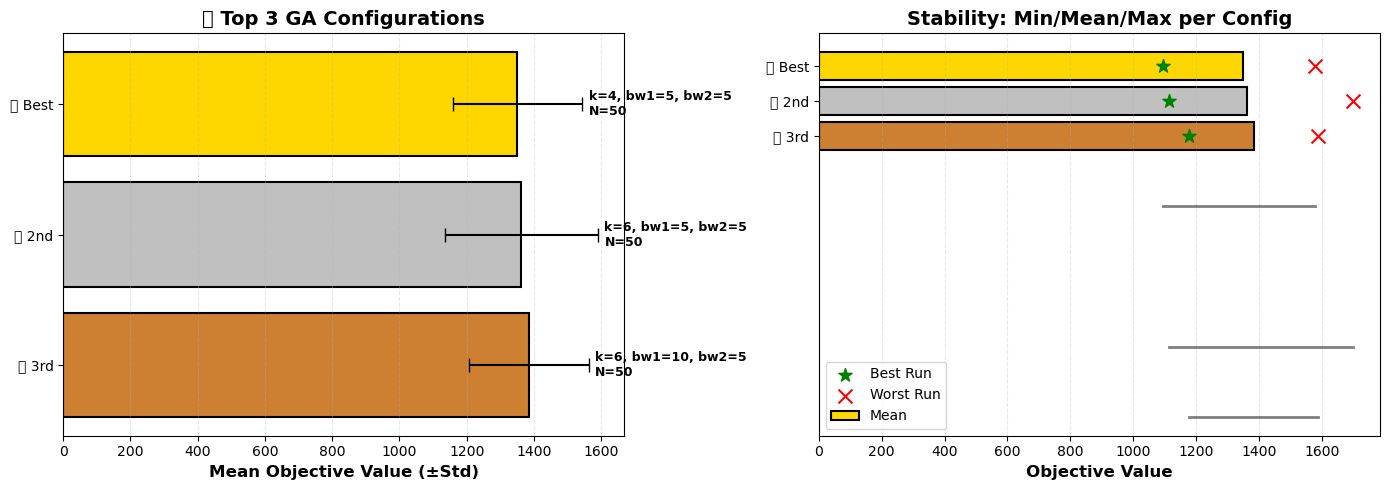


🏆 TOP 3 GENETIC ALGORITHM CONFIGURATIONS 🏆
  rank  N  k  bw1  bw2  obj_mean    obj_std  obj_min  obj_max
🥇 Best 50  4    5    5  1350.708 192.066959  1093.28  1577.22
 🥈 2nd 50  6    5    5  1362.400 227.255521  1113.48  1699.93
 🥉 3rd 50  6   10    5  1384.284 178.217037  1177.55  1586.23

✅ RECOMMENDED CONFIG:
   N=50, k=4, bw1=5, bw2=5
   Mean Objective: 1350.71 ± 192.07
   Best Run: 1093.28 | Worst Run: 1577.22


In [6]:
configs = df.groupby(['N', 'k', 'bw1', 'bw2']).agg({
    'objective': ['mean', 'std', 'min', 'max', 'count']
}).reset_index()

configs.columns = ['N', 'k', 'bw1', 'bw2', 'obj_mean', 'obj_std', 'obj_min', 'obj_max', 'n_runs']

# Create config label for plotting
configs['config'] = configs.apply(lambda x: f"k={int(x['k'])}, bw1={int(x['bw1'])}, bw2={int(x['bw2'])}", axis=1)

# Sort by mean objective and get top 3
top3 = configs.nsmallest(3, 'obj_mean').copy()
top3['rank'] = ['🥇 Best', '🥈 2nd', '🥉 3rd']

# === PLOT: Top 3 Configs ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Mean Objective with Error Bars
ax1.barh(top3['rank'], top3['obj_mean'], xerr=top3['obj_std'], 
         color=['gold', 'silver', '#CD7F32'], edgecolor='black', linewidth=1.5, capsize=5)
ax1.set_xlabel('Mean Objective Value (±Std)', fontsize=12, fontweight='bold')
ax1.set_title('🏆 Top 3 GA Configurations', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Add config labels
for i, row in top3.iterrows():
    ax1.text(row['obj_mean'] + row['obj_std'] + 20, row['rank'], 
             f"{row['config']}\nN={int(row['N'])}", 
             va='center', fontsize=9, fontweight='bold')

# Plot 2: Min/Mean/Max Range
positions = range(len(top3))
ax2.barh(positions, top3['obj_mean'], color=['gold', 'silver', '#CD7F32'], 
         edgecolor='black', linewidth=1.5, label='Mean')
ax2.scatter(top3['obj_min'], positions, color='green', s=100, zorder=3, label='Best Run', marker='*')
ax2.scatter(top3['obj_max'], positions, color='red', s=100, zorder=3, label='Worst Run', marker='x')

# Error bars showing range
for i, row in top3.iterrows():
    ax2.plot([row['obj_min'], row['obj_max']], [i, i], 'k-', linewidth=2, alpha=0.5)

ax2.set_yticks(positions)
ax2.set_yticklabels(top3['rank'])
ax2.set_xlabel('Objective Value', fontsize=12, fontweight='bold')
ax2.set_title('Stability: Min/Mean/Max per Config', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('top3_ga_configs.png', dpi=300, bbox_inches='tight')
plt.show()

# === OUTPUT TABLE ===
print("\n" + "="*80)
print("🏆 TOP 3 GENETIC ALGORITHM CONFIGURATIONS 🏆")
print("="*80)
print(top3[['rank', 'N', 'k', 'bw1', 'bw2', 'obj_mean', 'obj_std', 'obj_min', 'obj_max']].to_string(index=False))
print("="*80)

# Best config for deployment
best = top3.iloc[0]
print(f"\n✅ RECOMMENDED CONFIG:")
print(f"   N={int(best['N'])}, k={int(best['k'])}, bw1={int(best['bw1'])}, bw2={int(best['bw2'])}")
print(f"   Mean Objective: {best['obj_mean']:.2f} ± {best['obj_std']:.2f}")
print(f"   Best Run: {best['obj_min']:.2f} | Worst Run: {best['obj_max']:.2f}")
